In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
import itertools

policy = 0
metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/global_step"

api = wandb.Api()
#project = "xiaoxionglin-bernstein-center-freiburg/NEWymaze_norew_instr"
project = "xiaoxionglin-bernstein-center-freiburg/ENC_DECymaze_norew_instr"

runs = api.runs(project)

plt.rcParams.update({
    "font.size": 14, "font.family": "serif", "figure.figsize": (10, 6),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2.2, "savefig.dpi": 300
})

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/fr/fr_ze12/.netrc.


Usable runs: 30


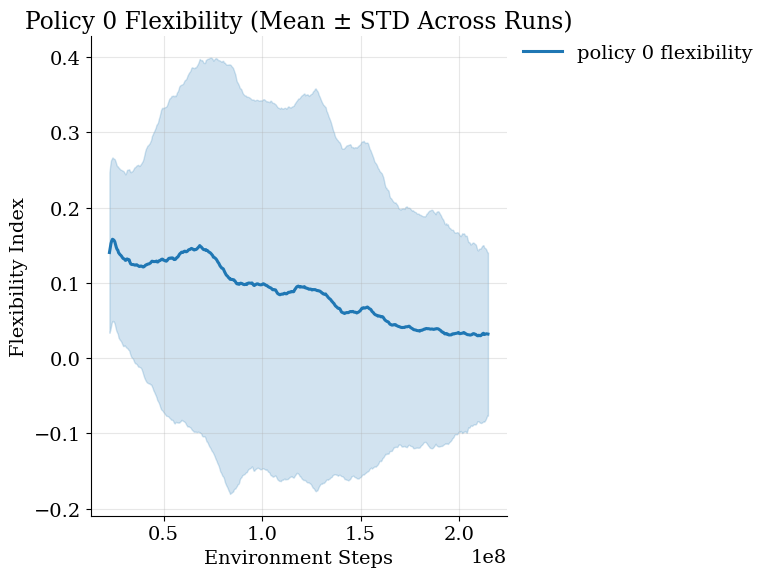

In [5]:
fig, ax = plt.subplots()

def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

resampled = []
steps = None

for run in runs:
    df = run.history(keys=[metric, step_col])
    if len(df) < 10:
        continue
    s, values = resample_run(df, step_col, metric)
    resampled.append(values)
    steps = s

print(f"Usable runs: {len(resampled)}")

if resampled:
    resampled = np.array(resampled)
    mean = resampled.mean(axis=0)
    std = resampled.std(axis=0)

    ax.plot(steps, mean, color="tab:blue", label=f"policy {policy} flexibility")
    ax.fill_between(steps, mean - std, mean + std, color="tab:blue", alpha=0.20)

ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_title(f"Policy {policy} Flexibility (Mean ± STD Across Runs)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Flexibility Index")

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

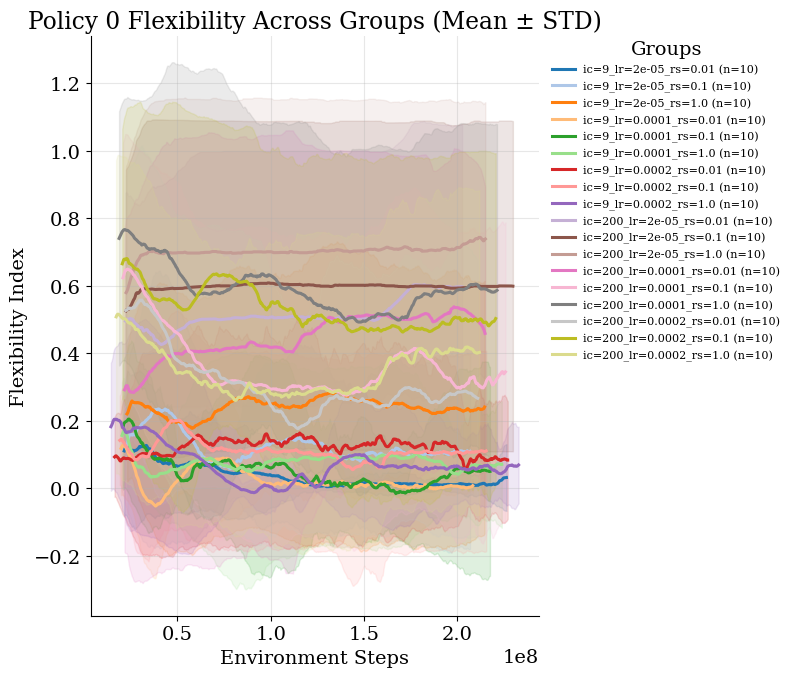

In [ ]:
policy = 0
metric = f"{policy}/custom/flexibility"
step_col = f"{policy}/global_step"

all_runs = api.runs(project)

records = []
for run in all_runs:
    records.append({
        "run": run, "run_id": run.id, "name": run.name,
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
    })

flex_df = pd.DataFrame(records)

instr_coeffs = sorted(flex_df["number_instruction_coef"].dropna().unique().tolist())
learning_rates = sorted(flex_df["learning_rate"].dropna().unique().tolist())
reward_scales = sorted(flex_df["reward_scale"].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab20.colors

def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    if df[step_col].nunique() < 2:
        return None, None
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

group_combos = list(itertools.product(instr_coeffs, learning_rates, reward_scales))

for gi, (ic, lr, rs) in enumerate(group_combos):
    color = colors[gi % len(colors)]
    group_label = f"ic={ic}_lr={lr}_rs={rs}"

    group_rows = flex_df[
        (flex_df["number_instruction_coef"] == ic) &
        (flex_df["learning_rate"] == lr) &
        (flex_df["reward_scale"] == rs)
    ]

    resampled, steps = [], None
    for _, row in group_rows.iterrows():
        df = row["run"].history(keys=[metric, step_col])
        if len(df) < 10:
            continue
        s, values = resample_run(df, step_col, metric)
        if s is None:
            continue
        resampled.append(values)
        steps = s

    if not resampled:
        print(f"No usable runs for group {group_label} (found {len(group_rows)} runs)")
        continue

    resampled = np.array(resampled)
    mean, std = resampled.mean(axis=0), resampled.std(axis=0)
    ax.plot(steps, mean, color=color, label=f"{group_label} (n={len(resampled)})")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

ax.legend(title="Groups", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
ax.set_title(f"Policy {policy} Flexibility Across Groups (Mean ± STD)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Flexibility Index")
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

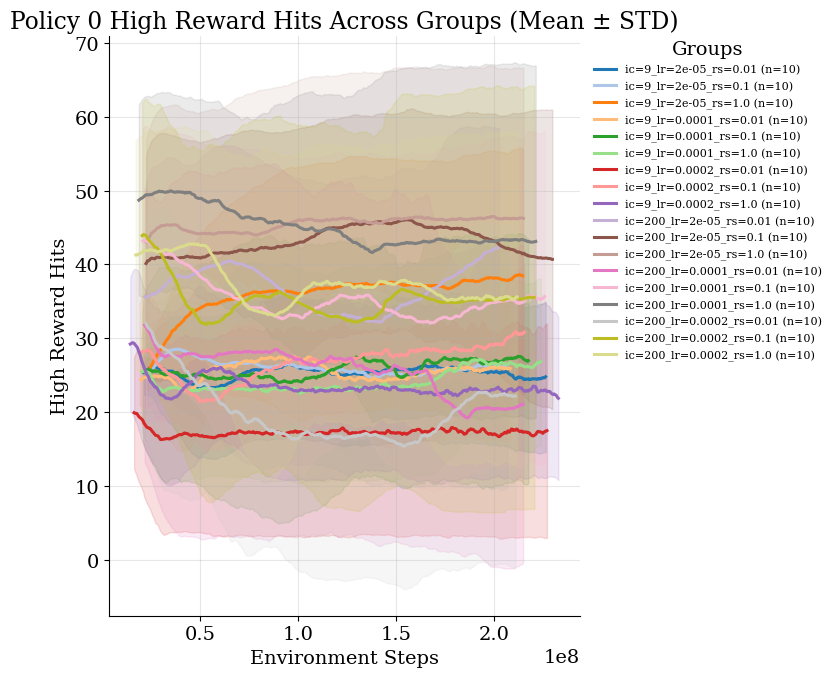

In [6]:
policy = 0
metric = f"{policy}/custom/highrew_hit"
step_col = f"{policy}/global_step"

all_runs = api.runs(project)

records = []
for run in all_runs:
    records.append({
        "run": run, "run_id": run.id, "name": run.name,
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
    })

reward_df = pd.DataFrame(records)

instr_coeffs = sorted(reward_df["number_instruction_coef"].dropna().unique().tolist())
learning_rates = sorted(reward_df["learning_rate"].dropna().unique().tolist())
reward_scales = sorted(reward_df["reward_scale"].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab20.colors

def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    if df[step_col].nunique() < 2:
        return None, None
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

group_combos = list(itertools.product(instr_coeffs, learning_rates, reward_scales))

for gi, (ic, lr, rs) in enumerate(group_combos):
    color = colors[gi % len(colors)]
    group_label = f"ic={ic}_lr={lr}_rs={rs}"

    group_rows = reward_df[
        (reward_df["number_instruction_coef"] == ic) &
        (reward_df["learning_rate"] == lr) &
        (reward_df["reward_scale"] == rs)
    ]

    resampled, steps = [], None
    for _, row in group_rows.iterrows():
        df = row["run"].history(keys=[metric, step_col])
        if len(df) < 10:
            continue
        s, values = resample_run(df, step_col, metric)
        if s is None:
            continue
        resampled.append(values)
        steps = s

    if not resampled:
        print(f"No usable runs for group {group_label} (found {len(group_rows)} runs)")
        continue

    resampled = np.array(resampled)
    mean, std = resampled.mean(axis=0), resampled.std(axis=0)
    ax.plot(steps, mean, color=color, label=f"{group_label} (n={len(resampled)})")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

ax.legend(title="Groups", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
ax.set_title(f"Policy {policy} High Reward Hits Across Groups (Mean ± STD)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("High Reward Hits")
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

### Functions to Filter out Runs

In [2]:
def analyze_run_stability(run, metric_key, step_col, tail_frac=0.2, min_points=20):
    """Summarize how stable a run is near the end of training.

    The function loads the run history for the requested metric and step column,
    keeps only valid rows, sorts them by step, and compares the first and last
    parts of the trajectory.
    ----------
    tail_frac : float, optional
        Fraction of the trajectory to use for the early/late summary windows.
    min_points : int, optional
        Minimum number of valid points required to return a result.
    """
    df = run.history(keys=[metric_key, step_col])
    df = df[[step_col, metric_key]].dropna().sort_values(step_col)
    if len(df) < min_points:
        return None

    n = len(df)
    tail_n = max(int(n * tail_frac), 10)
    tail = df.tail(tail_n)
    early = df.head(tail_n)

    return {
        "tail_mean": tail[metric_key].mean(),
        "tail_std": tail[metric_key].std(),
        "early_mean": early[metric_key].mean(),
        "n_points": n,
        "full_series": df,
    }


def is_len_steadily_decreasing(df, len_key, n_segments=5):
    """Check whether a length metric decreases in a broadly monotonic way.

    The series is split into equally sized segments, and the mean value in each
    segment is compared to look for a clear downward trend and limited rebound
    after the minimum segment.
    ----------
    n_segments : int, optional
        Number of equal segments used to summarize the trajectory.
    -------
    Return a boolean indicating whether the trajectory is steadily decreasing,
    together with the per-segment means.
    """
    if len(df) < n_segments * 5:
        return False, None

    segment_size = len(df) // n_segments
    segment_means = [
        df[len_key].iloc[i*segment_size:(i+1)*segment_size].mean()
        for i in range(n_segments)
    ]

    min_idx = int(np.argmin(segment_means))
    no_rebound = all(segment_means[j] <= segment_means[min_idx] * 1.15 for j in range(min_idx, n_segments))
    is_decreasing_trend = segment_means[-1] < segment_means[0] * 0.7
    return (is_decreasing_trend and no_rebound), segment_means


def find_convergence_and_plateau(run, metric_key, step_col, target, tol, min_plateau_steps=10e6):
    """Detect when a metric first enters a target band and how long it stays there.

    The function finds the first step where the metric falls within
    [target - tol, target + tol], then measures the longest continuous plateau
    within that band after convergence.
    ----------
    min_plateau_steps : float, optional
        Minimum plateau duration expected downstream by the caller.
    """
    df = run.history(keys=[metric_key, step_col])
    df = df[[step_col, metric_key]].dropna().sort_values(step_col)
    if len(df) < 10:
        return None

    metric = df[metric_key].values
    steps = df[step_col].values
    lower, upper = target - tol, target + tol
    in_band = (metric >= lower) & (metric <= upper)

    if not in_band.any():
        return {
            "converged": False,
            "first_converge_step": np.nan,
            "plateau_start_step": np.nan,
            "plateau_end_step": np.nan,
            "plateau_length_steps": 0,
            "plateau_mean": np.nan,
            "plateau_std": np.nan,
            "stayed_in_band_frac": 0.0,
            "n_points": len(df),
        }

    first_converge_idx = int(np.argmax(in_band))
    first_converge_step = steps[first_converge_idx]

    post_conv_in_band = in_band[first_converge_idx:]
    post_conv_steps = steps[first_converge_idx:]
    post_conv_metric = metric[first_converge_idx:]

    runs = []
    start = None
    for i, val in enumerate(post_conv_in_band):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(post_conv_in_band) - 1))

    longest_run = max(runs, key=lambda r: r[1] - r[0]) if runs else (0, 0)

    plateau_start_idx = first_converge_idx + longest_run[0]
    plateau_end_idx = first_converge_idx + longest_run[1]
    plateau_start_step = steps[plateau_start_idx]
    plateau_end_step = steps[plateau_end_idx]
    plateau_length_steps = plateau_end_step - plateau_start_step
    plateau_metric = metric[plateau_start_idx:plateau_end_idx+1]
    stayed_in_band_frac = post_conv_in_band.mean()

    return {
        "converged": True,
        "first_converge_step": first_converge_step,
        "plateau_start_step": plateau_start_step,
        "plateau_end_step": plateau_end_step,
        "plateau_length_steps": plateau_length_steps,
        "plateau_mean": plateau_metric.mean(),
        "plateau_std": plateau_metric.std(),
        "stayed_in_band_frac": stayed_in_band_frac,
        "n_points": len(df),
    }

In [6]:
FLEX_TARGET, REWARD_TARGET = 1.0, 60
FLEX_TOL, REWARD_TOL = 0.15, 5 # allowed deviation
FLEX_STD_MAX, REWARD_STD_MAX = 0.15, 8 # max allowed std, filter out too much fluctuation
TAIL_FRAC = 0.2 # fraction of the "tail" window of the total run to consider for stability analysis

policy = 0
flex_key = f"{policy}/custom/flexibility"
reward_key = f"{policy}/custom/highrew_hit"
len_key = f"{policy}/len/len"
step_col = f"{policy}/global_step"

all_runs = api.runs(project)

records = []
for run in all_runs:
    flex_stats = analyze_run_stability(run, flex_key, step_col, TAIL_FRAC)
    reward_stats = analyze_run_stability(run, reward_key, step_col, TAIL_FRAC)
    len_df = run.history(keys=[len_key, step_col])
    len_df = len_df[[step_col, len_key]].dropna().sort_values(step_col)

    if flex_stats is None or reward_stats is None or len_df.empty:
        continue

    flex_ok = abs(flex_stats["tail_mean"] - FLEX_TARGET) <= FLEX_TOL and flex_stats["tail_std"] <= FLEX_STD_MAX
    reward_ok = abs(reward_stats["tail_mean"] - REWARD_TARGET) <= REWARD_TOL and reward_stats["tail_std"] <= REWARD_STD_MAX
    len_ok, len_segments = is_len_steadily_decreasing(len_df, len_key)

    records.append({
        "run_id": run.id, "name": run.name,
        "flex_tail_mean": flex_stats["tail_mean"], "flex_tail_std": flex_stats["tail_std"],
        "reward_tail_mean": reward_stats["tail_mean"], "reward_tail_std": reward_stats["tail_std"],
        "len_ok": len_ok, "len_segments": len_segments,
        "flex_ok": flex_ok, "reward_ok": reward_ok,
        "all_ok": flex_ok and reward_ok and len_ok,
    })

results_df = pd.DataFrame(records)
selected = results_df[results_df["all_ok"]].sort_values("reward_tail_mean", ascending=False)
results_df.to_csv("all_run_stats_encoderonly.csv", index=False)
selected.to_csv("selected_runs_encoderonly.csv", index=False)
print(f"Total analyzed: {len(results_df)}, matching all criteria: {len(selected)}")

Total analyzed: 30, matching all criteria: 0


In [3]:
MIN_PLATEAU_STEPS = 10e6  # must stay in band for at least 10M steps
FLEX_TARGET, REWARD_TARGET = 1.0, 60
FLEX_TOL, REWARD_TOL = 0.15, 5 # allowed deviation
FLEX_STD_MAX, REWARD_STD_MAX = 0.15, 8 # max allowed std, filter out too much fluctuation
TAIL_FRAC = 0.2 # fraction of the "tail" window of the total run to consider for stability analysis

policy = 0
flex_key = f"{policy}/custom/flexibility"
reward_key = f"{policy}/custom/highrew_hit"
len_key = f"{policy}/len/len"
step_col = f"{policy}/global_step"

all_runs = api.runs(project)


records = []
for run in all_runs:
    flex_plateau = find_convergence_and_plateau(run, flex_key, step_col, FLEX_TARGET, FLEX_TOL, MIN_PLATEAU_STEPS)
    reward_plateau = find_convergence_and_plateau(run, reward_key, step_col, REWARD_TARGET, REWARD_TOL, MIN_PLATEAU_STEPS)
    len_df = run.history(keys=[len_key, step_col])
    len_df = len_df[[step_col, len_key]].dropna().sort_values(step_col)

    if flex_plateau is None or reward_plateau is None or len_df.empty:
        continue

    flex_ok = (
        flex_plateau["converged"]
        and flex_plateau["plateau_length_steps"] >= MIN_PLATEAU_STEPS
        and flex_plateau["stayed_in_band_frac"] >= 0.8  # at least 80% of post-convergence time in band
        and flex_plateau["plateau_std"] <= 0.15
    )
    reward_ok = (
        reward_plateau["converged"]
        and reward_plateau["plateau_length_steps"] >= MIN_PLATEAU_STEPS
        and reward_plateau["stayed_in_band_frac"] >= 0.8
        and reward_plateau["plateau_std"] <= 8
    )
    len_ok, len_segments = is_len_steadily_decreasing(len_df, len_key)

    records.append({
        "run_id": run.id, "name": run.name,
        # Hyperparameters 
        "seed": run.config.get("seed"),
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
        # Flexibility and high-reward hit plateau analysis
        "flex_converged": flex_plateau["converged"],
        "flex_plateau_length": flex_plateau["plateau_length_steps"],
        "flex_plateau_mean": flex_plateau["plateau_mean"],
        "flex_plateau_std": flex_plateau["plateau_std"],
        "reward_converged": reward_plateau["converged"],
        "reward_plateau_length": reward_plateau["plateau_length_steps"],
        "reward_plateau_mean": reward_plateau["plateau_mean"],
        "reward_plateau_std": reward_plateau["plateau_std"],
        "first_converge_reward_step": reward_plateau["first_converge_step"],
        "first_converge_flex_step": flex_plateau["first_converge_step"],
        # Episode length analysis
        "len_ok": len_ok,
        "len_segments": len_segments,
        # Selection
        "flex_ok": flex_ok, "reward_ok": reward_ok,
        "all_ok": flex_ok and reward_ok and len_ok,
    })

results_df_plat = pd.DataFrame(records)

selected_plat = results_df_plat[results_df_plat["all_ok"]].sort_values("reward_plateau_mean", ascending=False)
#results_df_plat.to_csv("all_run_stats_plateau_encoderonly.csv", index=False)
#selected_plat.to_csv("selected_runs_plateau_encoderonly.csv", index=False)
print(f"Total: {len(results_df_plat)}, matching all: {len(selected_plat)}")

Total: 40, matching all: 1


In [ ]:
import wandb
wandb.login(relogin=True)  # or wandb.login(key="...") if needed
api = wandb.Api(timeout=60)
all_runs = api.runs(project)  # re-fetch live run objects

### Selected Runs Plot

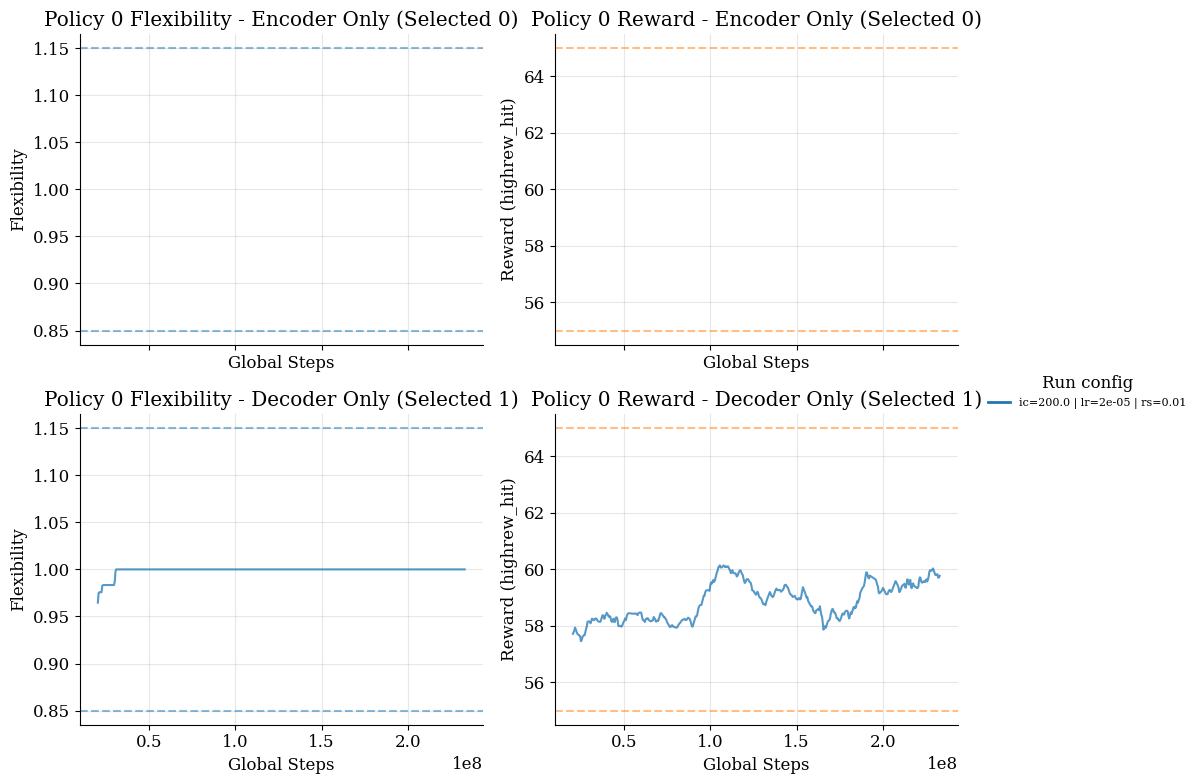

In [6]:
selected_ids = set(selected_plat["run_id"].tolist())
policy = 0
flex_key = f"{policy}/custom/flexibility"
reward_key = f"{policy}/custom/highrew_hit"
step_col = f"{policy}/global_step"

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "figure.figsize": (12, 8),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 1.5,
})

fig, axes = plt.subplots(2, 2, sharex=True)

records = []
for run_id in selected_ids:
    run = api.run(f"{project}/{run_id}")
    name_lower = run.name.lower() if run.name else ""
    if "encoderonly" in name_lower:
        run_type = "encoderonly"
    elif "decoderonly" in name_lower:
        run_type = "decoderonly"
    else:
        run_type = None

    records.append({
        "run": run,
        "run_id": run.id,
        "name": run.name,
        "run_type": run_type,
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
    })

runs_df = pd.DataFrame(records)
runs_df = runs_df[runs_df["run_type"].notna()].copy()

# count the runs per type
for run_type in ["encoderonly", "decoderonly"]:
    count = len(runs_df[runs_df["run_type"] == run_type])
    if run_type == "encoderonly":
        encoderonly_count = count
    elif run_type == "decoderonly":
        decoderonly_count = count


# metric_specs = [
#     ("sigmoid", flex_key, "Flexibility", (0, 0), f"Policy {policy} Flexibility - Sigmoid (Selected {sig_count})"),
#     ("sigmoid", reward_key, "Reward (highrew_hit)", (0, 1), f"Policy {policy} Reward - Sigmoid (Selected {sig_count})"),
#     ("newmod", flex_key, "Flexibility", (1, 0), f"Policy {policy} Flexibility - Newmod (Selected {newmod_count})"),
#     ("newmod", reward_key, "Reward (highrew_hit)", (1, 1), f"Policy {policy} Reward - Newmod (Selected {newmod_count})"),
# ]


metric_specs = [("encoderonly", flex_key, "Flexibility", (0, 0), f"Policy {policy} Flexibility - Encoder Only (Selected {encoderonly_count})"),
                ("encoderonly", reward_key, "Reward (highrew_hit)", (0, 1), f"Policy {policy} Reward - Encoder Only (Selected {encoderonly_count})"),
                ("decoderonly", flex_key, "Flexibility", (1, 0), f"Policy {policy} Flexibility - Decoder Only (Selected {decoderonly_count})"),
                ("decoderonly", reward_key, "Reward (highrew_hit)", (1, 1), f"Policy {policy} Reward - Decoder Only (Selected {decoderonly_count})"),]


config_cols = ["number_instruction_coef", "learning_rate", "reward_scale"]
config_combos = sorted(
    runs_df[config_cols]
    .dropna()
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)

colors = plt.cm.tab20.colors
color_map = {combo: colors[i % len(colors)] for i, combo in enumerate(config_combos)}


def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna().sort_values(step_col)
    if len(df) < 2 or df[step_col].nunique() < 2:
        return None, None
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values


for run_type, metric_key, y_label, (row_idx, col_idx), title in metric_specs:
    ax = axes[row_idx, col_idx]
    subset = runs_df[runs_df["run_type"] == run_type]

    for _, row in subset.iterrows():
        df = row["run"].history(keys=[metric_key, step_col])
        if len(df) < 10:
            continue

        steps, values = resample_run(df, step_col, metric_key)
        if steps is None:
            continue

        combo = (row["number_instruction_coef"], row["learning_rate"], row["reward_scale"])
        if combo not in color_map:
            continue

        label = f"ic={combo[0]} | lr={combo[1]} | rs={combo[2]}"
        ax.plot(steps, values, color=color_map[combo], alpha=0.75, label=label)

    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_xlabel("Global Steps")

    if metric_key == flex_key:
        ax.axhline(FLEX_TARGET - FLEX_TOL, color="tab:blue", linestyle="--", alpha=0.5)
        ax.axhline(FLEX_TARGET + FLEX_TOL, color="tab:blue", linestyle="--", alpha=0.5)
    else:
        ax.axhline(REWARD_TARGET - REWARD_TOL, color="tab:orange", linestyle="--", alpha=0.5)
        ax.axhline(REWARD_TARGET + REWARD_TOL, color="tab:orange", linestyle="--", alpha=0.5)

handles = [
    plt.Line2D([0], [0], color=color_map[combo], linewidth=2, label=f"ic={combo[0]} | lr={combo[1]} | rs={combo[2]}")
    for combo in config_combos
]

if handles:
    fig.legend(handles=handles, title="Run config", frameon=False, loc="center right", fontsize=8)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig("selected_runs_metrics_plat_encodervsdecoder.png", dpi=300)
plt.show()

In [ ]:
from pathlib import Path

notebook_dir = Path("/home/fr/fr_ze12/SF_hipposlam/sf_working_directories/zeynep/analysis")
selected_runs = pd.read_csv(notebook_dir / "selected_runs_encoderonly.csv")
selected_runs_plateau = pd.read_csv(notebook_dir / "selected_runs_plateau_encoderonly.csv")

common_run_ids = sorted(
    set(selected_runs["run_id"].dropna()) & set(selected_runs_plateau["run_id"].dropna())
)

common_selected_runs = selected_runs[selected_runs["run_id"].isin(common_run_ids)].copy()
common_selected_runs_plateau = selected_runs_plateau[selected_runs_plateau["run_id"].isin(common_run_ids)].copy()

print(f"Common run_id count: {len(common_run_ids)}")
print(common_run_ids)

common_selected_runs.to_csv(notebook_dir / "selected_runs_common.csv", index=False)
common_selected_runs_plateau.to_csv(notebook_dir / "selected_runs_plateau_common.csv", index=False)

common_selected_runs

#### Compare convergence speed and plateau quality

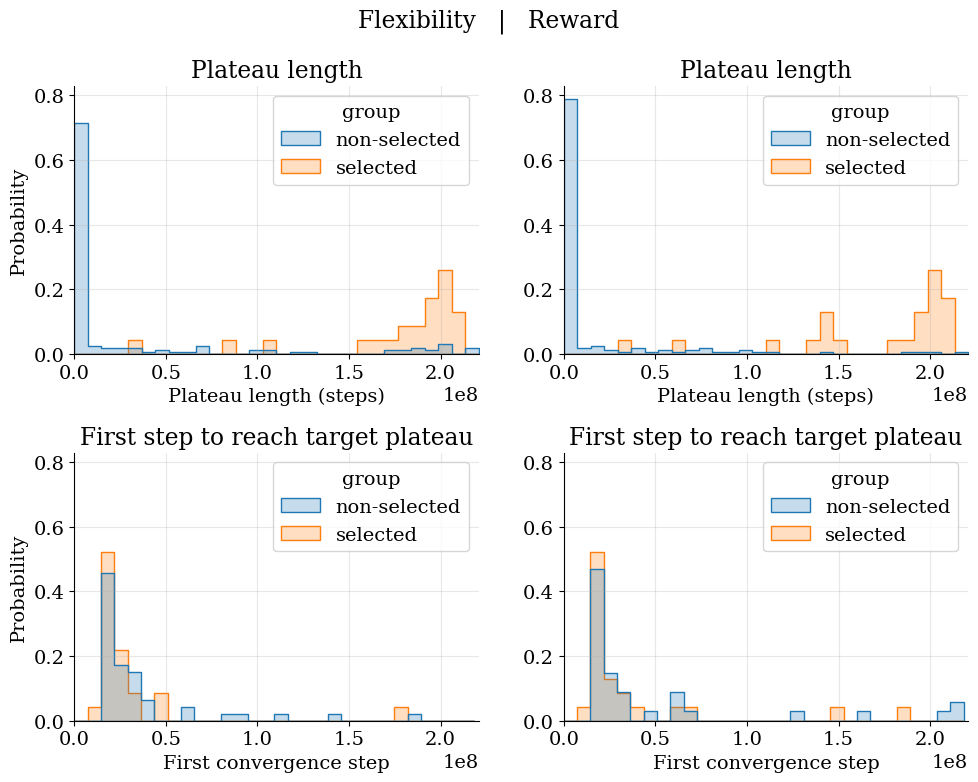

In [ ]:
import seaborn as sns

df = results_df_plat.copy()
df["group"] = df["all_ok"].map({True: "selected", False: "non-selected"})

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Use a single shared x-range across all four histograms for direct comparison
all_x_values = pd.concat([
    df["flex_plateau_length"].dropna(),
    df["reward_plateau_length"].dropna(),
    df[df["flex_converged"]]["first_converge_flex_step"].dropna(),
    df[df["reward_converged"]]["first_converge_reward_step"].dropna(),
]).dropna()
if not all_x_values.empty:
    shared_x_min = all_x_values.min()
    shared_x_max = all_x_values.max()
    for ax in axes.flat:
        ax.set_xlim(shared_x_min, shared_x_max)

max_plateau = max(df["flex_plateau_length"].max(),df["reward_plateau_length"].max(),)
plateau_bins = np.linspace(0, max_plateau, 31)

max_reach = max(df.loc[df["flex_converged"], "first_converge_flex_step"].max(), df.loc[df["reward_converged"], "first_converge_reward_step"].max())
reach_bins = np.linspace(0, max_reach, 31)

# Flexibility plateau length
sns.histplot(df, x="flex_plateau_length", hue="group", bins=plateau_bins, stat="probability", common_norm=False, ax=axes[0,0], element="step")
axes[0,0].set_xlabel("Plateau length (steps)")
axes[0,0].set_title("Plateau length")

# Reward plateau length
sns.histplot(df, x="reward_plateau_length", hue="group", bins=plateau_bins, stat="probability", common_norm=False, ax=axes[0,1], element="step")
axes[0,1].set_xlabel("Plateau length (steps)")
axes[0,1].set_ylabel(" ")
axes[0,1].set_title("Plateau length")

# First convergence step (flex)
sns.histplot(df[df["flex_converged"]], x="first_converge_flex_step", bins=reach_bins, stat="probability", common_norm=False, hue="group", ax=axes[1,0], element="step")
axes[1,0].set_xlabel("First convergence step")
axes[1,0].set_title("First step to reach target plateau")

# First convergence step (reward)
sns.histplot(df[df["reward_converged"]], x="first_converge_reward_step", bins=reach_bins, stat="probability", common_norm=False, hue="group", ax=axes[1,1], element="step")
axes[1,1].set_xlabel("First convergence step")
axes[1,1].set_ylabel(" ")
axes[1,1].set_title("First step to reach target plateau")

# Keep the same y range across all four histograms as well
shared_y_max = max(ax.get_ylim()[1] for ax in axes.flat)
for ax in axes.flat:
    ax.set_ylim(0, shared_y_max)

fig.suptitle("Flexibility   |   Reward")

plt.tight_layout()
plt.savefig("plateau_length_and_convergence_histograms_encoderonly.png", dpi=300)
plt.show()

# Early acquisition of the desired behavior is not sufficient. The selected runs are distinguished mainly by their ability 
# to maintain the behavior over a long interval.

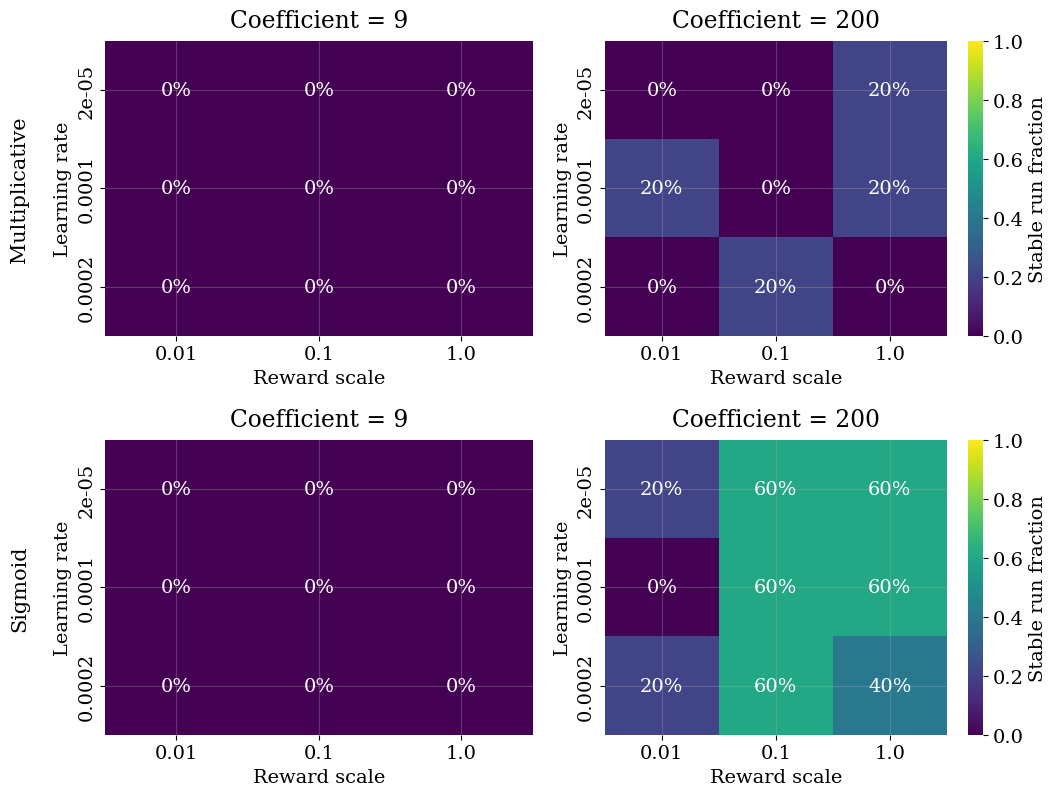

In [57]:
analysis_df = results_df_plat.copy()

modulations = sorted(analysis_df["INSTR_modulation"].dropna().unique())
instr_coefs = sorted(analysis_df["number_instruction_coef"].dropna().unique())

group_cols = [
    "INSTR_modulation",
    "number_instruction_coef",
    "learning_rate",
    "reward_scale",
]

config_success = (
    analysis_df
    .groupby(group_cols, dropna=False)
    .agg(
        n_runs=("run_id", "size"),
        n_selected=("all_ok", "sum"),
        success_rate=("all_ok", "mean"),
        median_flex_plateau=("flex_plateau_length", "median"),
        median_reward_plateau=("reward_plateau_length", "median"),
    )
    .reset_index()
)

config_success["success_percent"] = 100 * config_success["success_rate"]

config_success = config_success.sort_values(
    ["success_rate", "n_selected", "n_runs"],
    ascending=False,
)

#print(config_success.to_string(index=False))

modulation_order = ["multiply", "sigmoid"]
modulations = [m for m in modulation_order if m in analysis_df["INSTR_modulation"].dropna().unique()]
instr_coefs = sorted(analysis_df["number_instruction_coef"].dropna().unique())

fig, axes = plt.subplots(
    len(modulations),
    len(instr_coefs),
    figsize=(6 * len(instr_coefs), 4.5 * len(modulations)),
    squeeze=False,
)

for i, modulation in enumerate(modulations):
    for j, instr_coef in enumerate(instr_coefs):
        ax = axes[i, j]

        subset = config_success[
            (config_success["INSTR_modulation"] == modulation)
            & (config_success["number_instruction_coef"] == instr_coef)
        ]

        heatmap_data = subset.pivot(
            index="learning_rate",
            columns="reward_scale",
            values="success_rate",
        )

        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".0%",
            vmin=0,
            vmax=1,
            cmap="viridis",
            cbar=(j == len(instr_coefs) - 1),
            cbar_kws={"label": "Stable run fraction"},
            ax=ax,
        )

        ax.set_xlabel("Reward scale")
        ax.set_ylabel("Learning rate")
        ax.set_title(f"Coefficient = {instr_coef}", pad=10)

for i, modulation in enumerate(modulations):
    row_label = "Multiplicative" if modulation == "multiply" else "Sigmoid"
    axes[i, 0].text(-0.2, 0.5, row_label, transform=axes[i, 0].transAxes, rotation=90, va="center", ha="center", fontsize=15)

annot = config_success.assign(
    annotation=config_success.apply(
        lambda r: f"{int(r['n_selected'])}/{int(r['n_runs'])}\n"
                  f"({r['success_percent']:.0f}%)",
        axis=1,
    )
)

plt.tight_layout(rect=[0.06, 0.05, 0.96, 0.96])
plt.savefig("success_rate_heatmaps.png", dpi=300)
plt.show()

Matched condition:
  INSTR_modulation: sigmoid
  number_instruction_coef: 200
  learning_rate: all
  reward_scale: all

Learning-state counts:
learning_class
Sustained learner          19
Transient joint learner    13
Never/partial learner      13
Name: count, dtype: int64

Usable histories:
Sustained learner: {'flex': 19, 'reward': 19, 'len': 19}
Transient joint learner: {'flex': 13, 'reward': 13, 'len': 13}
Never/partial learner: {'flex': 13, 'reward': 13, 'len': 13}


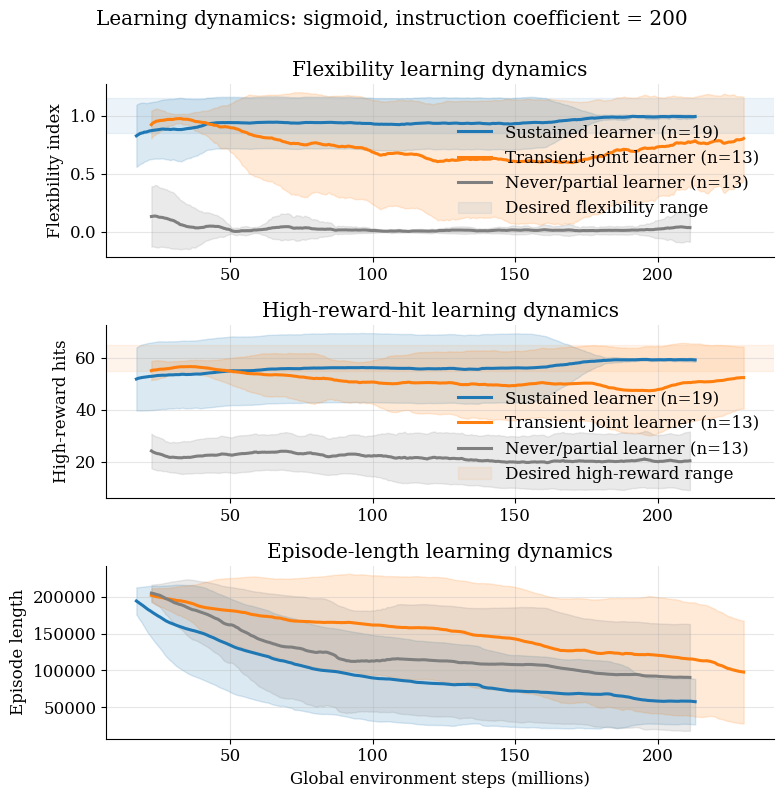

In [ ]:
# Match these hyperparameters across the compared runs.
MATCH_MODULATION = "sigmoid"
MATCH_COEFFICIENT = 200
MATCH_LEARNING_RATE = None       
MATCH_REWARD_SCALE = None        

NUM_POINTS = 500
MAX_STEP = None  # avoid late training collapse; set None to use full trajectories

classes = [
    "Sustained learner",
    "Transient joint learner",
    "Never/partial learner",
]

colors = {
    "Sustained learner": "tab:blue",
    "Transient joint learner": "tab:orange",
    "Never/partial learner": "tab:gray",
}

# ------------------------------------------------------------
# W&B RUNS + CONFIG METADATA
# ------------------------------------------------------------
api = wandb.Api()
all_runs = api.runs(project)

config_records = []
for run in all_runs:
    config_records.append({
        "run_id": run.id,
        "seed": run.config.get("seed"),
        "INSTR_modulation": run.config.get("INSTR_modulation"),
        "number_instruction_coef": run.config.get("number_instruction_coef"),
        "learning_rate": run.config.get("learning_rate"),
        "reward_scale": run.config.get("reward_scale"),
    })

config_df = pd.DataFrame(config_records)

analysis_df = results_df_plat.copy()

# ------------------------------------------------------------
# LEARNING-STATE LABELS
# ------------------------------------------------------------
analysis_df["learning_class"] = np.select(
    [
        analysis_df["all_ok"],

        # Reached BOTH behavioural bands but failed persistence/length criteria.
        (analysis_df["flex_plateau_length"] > 0) &
        (analysis_df["reward_plateau_length"] > 0),
    ],
    [
        "Sustained learner",
        "Transient joint learner",
    ],
    default="Never/partial learner",
)

# ------------------------------------------------------------
# SELECT MATCHED HYPERPARAMETER CONDITION
# ------------------------------------------------------------
matched_df = analysis_df[
    (analysis_df["INSTR_modulation"].astype(str).str.lower() == MATCH_MODULATION.lower()) &
    (analysis_df["number_instruction_coef"] == MATCH_COEFFICIENT)
].copy()

if MATCH_LEARNING_RATE is not None:
    matched_df = matched_df[
        np.isclose(matched_df["learning_rate"], MATCH_LEARNING_RATE)
    ]

if MATCH_REWARD_SCALE is not None:
    matched_df = matched_df[
        np.isclose(matched_df["reward_scale"], MATCH_REWARD_SCALE)
    ]

print("Matched condition:")
print(f"  INSTR_modulation: {MATCH_MODULATION}")
print(f"  number_instruction_coef: {MATCH_COEFFICIENT}")
print(f"  learning_rate: {MATCH_LEARNING_RATE if MATCH_LEARNING_RATE is not None else 'all'}")
print(f"  reward_scale: {MATCH_REWARD_SCALE if MATCH_REWARD_SCALE is not None else 'all'}")
print("\nLearning-state counts:")
print(matched_df["learning_class"].value_counts().reindex(classes, fill_value=0))

if matched_df.empty:
    raise ValueError("No runs match this condition. Check config values.")

# Use only runs that survived your plateau analysis.
run_by_id = {run.id: run for run in all_runs}
matched_runs = [
    (run_by_id[row["run_id"]], row["learning_class"])
    for _, row in matched_df.iterrows()
    if row["run_id"] in run_by_id
]

# ------------------------------------------------------------
# RESAMPLE
# ------------------------------------------------------------
def resample_run(df, step_col, metric_key, num_points=500, max_step=None):
    df = df[[step_col, metric_key]].dropna().sort_values(step_col)
    df = df.drop_duplicates(subset=step_col, keep="last")

    if max_step is not None:
        df = df[df[step_col] <= max_step]

    if len(df) < 2 or df[step_col].nunique() < 2:
        return None, None

    steps = np.linspace(
        df[step_col].min(),
        df[step_col].max(),
        num_points,
    )
    values = np.interp(steps, df[step_col], df[metric_key])
    return steps, values

# Each learning-state / metric combination receives a list of resampled curves.
curves = {
    cls: {
        flex_key: [],
        reward_key: [],
        len_key: [],
    }
    for cls in classes
}

# We retain the x-axis from the final usable curve per state/metric, matching
# the earlier approach. If run horizons are nearly identical, this is fine.
state_steps = {
    cls: {
        flex_key: None,
        reward_key: None,
        len_key: None,
    }
    for cls in classes
}

for run, learning_class in matched_runs:
    for metric_key in [flex_key, reward_key, len_key]:
        try:
            hist = run.history(
                keys=[metric_key, step_col],
                samples=1000,
                pandas=True,
            )
        except Exception as exc:
            print(f"Skipping {run.id}, {metric_key}: {type(exc).__name__}")
            continue

        if hist.empty or metric_key not in hist.columns or step_col not in hist.columns:
            continue

        steps, values = resample_run(
            hist,
            step_col,
            metric_key,
            num_points=NUM_POINTS,
            max_step=MAX_STEP,
        )

        if steps is None:
            continue

        curves[learning_class][metric_key].append(values)
        state_steps[learning_class][metric_key] = steps

print("\nUsable histories:")
for cls in classes:
    print(
        f"{cls}:",
        {
            "flex": len(curves[cls][flex_key]),
            "reward": len(curves[cls][reward_key]),
            "len": len(curves[cls][len_key]),
        },
    )

# ------------------------------------------------------------
# PLOT: MEAN ± STANDARD DEVIATION OVER RUNS
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "figure.figsize": (11, 10),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
})

fig, axes = plt.subplots(3, 1, figsize=(8, 8))

metric_info = [
    (flex_key, "Flexibility index", "Flexibility learning dynamics"),
    (reward_key, "High-reward hits", "High-reward-hit learning dynamics"),
    (len_key, "Episode length", "Episode-length learning dynamics"),
]

for ax, (metric_key, ylabel, title) in zip(axes, metric_info):
    for cls in classes:
        if not curves[cls][metric_key]:
            continue

        arr = np.asarray(curves[cls][metric_key])
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        steps = state_steps[cls][metric_key]

        ax.plot(
            steps / 1e6,
            mean,
            color=colors[cls],
            label=f"{cls} (n={len(arr)})",
        )
        ax.fill_between(
            steps / 1e6,
            mean - std,
            mean + std,
            color=colors[cls],
            alpha=0.16,
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)

# Reference bands used in your plateau definition.
axes[0].axhspan(
    FLEX_TARGET - FLEX_TOL,
    FLEX_TARGET + FLEX_TOL,
    color="tab:blue",
    alpha=0.08,
    label="Desired flexibility range",
)

axes[1].axhspan(
    REWARD_TARGET - REWARD_TOL,
    REWARD_TARGET + REWARD_TOL,
    color="tab:orange",
    alpha=0.08,
    label="Desired high-reward range",
)

axes[0].legend(frameon=False, loc="best")
axes[1].legend(frameon=False, loc="best")
axes[2].set_xlabel("Global environment steps (millions)")

fig.suptitle(
    f"Learning dynamics: {MATCH_MODULATION}, "
    f"instruction coefficient = {MATCH_COEFFICIENT}",
    y=0.995,
)

plt.tight_layout()
plt.savefig("Learning_dynamics_mean_std.png", dpi=300)
plt.show()


Usable entropy trajectories:
  Sustained learner: n=19
  Transient joint learner: n=13
  Never/partial learner: n=13


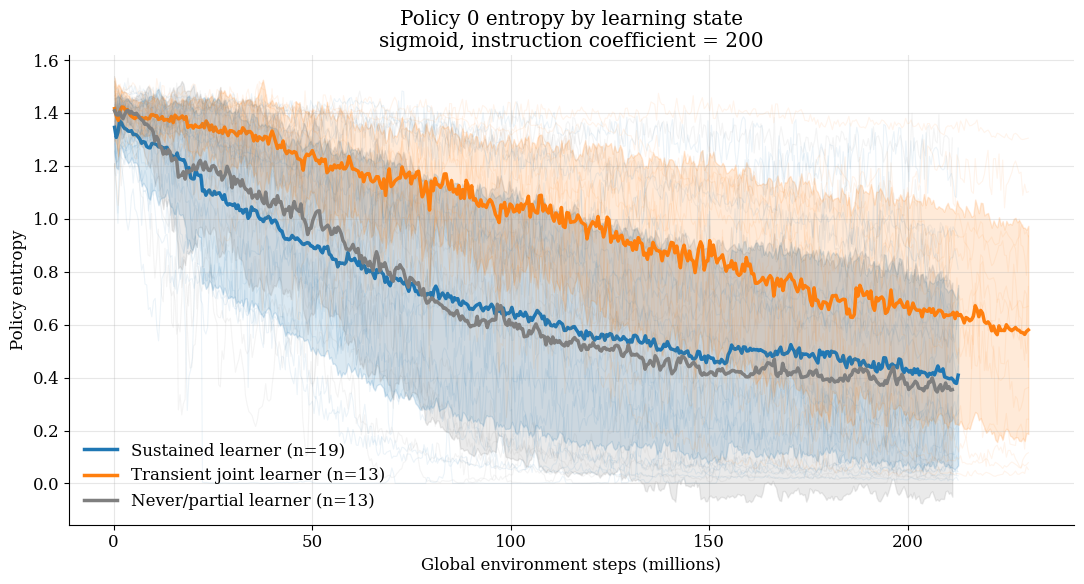

In [16]:
entropy_key = "0/train/entropy"
step_col = "0/global_step"

run_by_id = {run.id: run for run in all_runs}

entropy_curves = {cls: [] for cls in classes}
entropy_steps = {cls: None for cls in classes}

for _, row in matched_df.iterrows():
    run_id = row["run_id"]
    learning_class = row["learning_class"]

    run = run_by_id.get(run_id)
    if run is None:
        continue

    try:
        hist = run.history(
            keys=[entropy_key, step_col],
            samples=1000,
            pandas=True,
        )
    except Exception as exc:
        print(f"Skipping {run_id}: {type(exc).__name__}")
        continue

    if hist.empty or entropy_key not in hist.columns or step_col not in hist.columns:
        continue

    steps, values = resample_run(
        hist,
        step_col=step_col,
        metric_key=entropy_key,
        num_points=NUM_POINTS,
        max_step=MAX_STEP,
    )

    if steps is None:
        continue

    entropy_curves[learning_class].append(values)
    entropy_steps[learning_class] = steps

print("\nUsable entropy trajectories:")
for cls in classes:
    print(f"  {cls}: n={len(entropy_curves[cls])}")

# ------------------------------------------------------------
# PLOT RAW TRACES + CLASS MEAN ± SD
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
})

fig, ax = plt.subplots()

for cls in classes:
    if not entropy_curves[cls]:
        continue

    arr = np.asarray(entropy_curves[cls])
    steps = entropy_steps[cls] / 1e6

    # Faint individual trajectories reveal whether the mean hides subgroups.
    for curve in arr:
        ax.plot(
            steps,
            curve,
            color=colors[cls],
            alpha=0.08,
            linewidth=0.8,
        )

    mean = arr.mean(axis=0)
    std = arr.std(axis=0)

    ax.plot(
        steps,
        mean,
        color=colors[cls],
        linewidth=2.5,
        label=f"{cls} (n={len(arr)})",
    )
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=colors[cls],
        alpha=0.16,
    )

ax.set_xlabel("Global environment steps (millions)")
ax.set_ylabel("Policy entropy")
ax.set_title(
    f"Policy {policy} entropy by learning state\n"
    f"{MATCH_MODULATION}, instruction coefficient = {MATCH_COEFFICIENT}"
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [17]:
def mean_entropy_windows(run, entropy_key, step_col, plateau_end_step):
    df = run.history(keys=[entropy_key, step_col])
    df = df[[step_col, entropy_key]].dropna().sort_values(step_col)

    # Windows of 10M global steps just before and just after plateau end.
    window = 10e6
    before = df[
        (df[step_col] >= plateau_end_step - window) &
        (df[step_col] < plateau_end_step)
    ][entropy_key]

    after = df[
        (df[step_col] >= plateau_end_step) &
        (df[step_col] < plateau_end_step + window)
    ][entropy_key]

    return {
        "entropy_before_collapse": before.mean(),
        "entropy_after_collapse": after.mean(),
        "entropy_change": after.mean() - before.mean(),
    }